# Problem

**State space.**
The states are encoded as integers
$$\mathcal{X} = {0,1,\dots,8} $$
corresponding to the grid in row-major order (top-left corner to bottom-right corner). State $8$ is the terminal goal state and is absorbing.

**Action space.**
Actions are represented as integers

$$ \mathcal{A} = {0,1,2,3} $$

where $0 =$ Up, $1 =$ Down, $2 =$ Left, $3 =$ Right.

**Transition dynamics.**
Transitions are deterministic. For any state $x$ and action $a$, the state index is first mapped to its grid coordinates $(r,c)$, the action moves the agent one step (unless this would leave the grid), and the result is mapped back to a state index. The goal state $8$ always transitions to itself.
The transition matrix $P$ has shape $(|\mathcal{X}||\mathcal{A}|) \times |\mathcal{X}| = 36 \times 9$, where each row corresponds to a pair $(x,a)$ and contains a one-hot vector indicating the unique next state:

$$P[(x,a),x'] = 1 \quad \text{iff } x' = \text{next\_state}(x,a)$$

and $0$ otherwise.

**Reward model.**
Thus $r(x,a) = 1$ only when $x$ is the goal state, and $0$ otherwise.

**Initial state.**
The initial state is fixed as $x_0 = 0$.

In [41]:
%load_ext autoreload
%autoreload 2

import os
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

SEED = 42
DEVICE = "cpu"
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def tensor64(data):
    return torch.as_tensor(data, dtype=torch.float64, device=DEVICE)


def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path


PROJECT_ROOT = find_root(Path.cwd())

DATASETS_DIR = PROJECT_ROOT / "data" / "datasets_clean"
RESULTS_DIR = PROJECT_ROOT / "data" / "results_clean"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

DATASETS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from rl_methods.mdp_clean import DiscreteMDP, Planner
from rl_methods.fogas_clean import (
    FOGASOracleSolver,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASSolver,
)
from rl_methods.data_collection_clean import DiscreteDataBuffer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Tabular Features

## Definition

### Description

**Feature Map**

We use a tabular one-hot feature representation over state–action pairs.
Each feature corresponds to a unique \((x,a)\) combination.

The feature map is defined as:
$$
\phi(x,a) \in \mathbb{R}^{36}
$$
with the ordering
$$
(x,a) \;\longrightarrow\; e_{\,x \cdot |\mathcal{A}| + a}
\quad |\mathcal{A}| = 4
$$

**Reward Weights**

The reward function is linear in the features:
$$
r(x,a) = \phi(x,a)^\top \omega.
$$

The weight vector $\omega \in \mathbb{R}^{36}$ is defined as:
$$
\omega_i =
\begin{cases}
1 & \text{if } i \in \{8\cdot 4,\, 8\cdot 4 + 1,\, 8\cdot 4 + 2,\, 8\cdot 4 + 3\}, \\
0 & \text{otherwise}.
\end{cases}
$$

This yields:
$$
r(x,a) =
\begin{cases}
1 & \text{if } x = 8 \;\;(\text{goal state}), \\
0 & \text{otherwise}.
\end{cases}
$$

**Transition Weights**

For each $x' \in \mathcal{X}$,
$$
\psi(x')_i =
\begin{cases}
1 & \text{if } i = 4x + a \text{ and } x' = \text{next\_state}(x,a), \\
0 & \text{otherwise}.
\end{cases}
$$

Equivalently, stacking $\psi(x')$ for all $x'$ recovers the tabular
transition matrix
$$
P \in \mathbb{R}^{36 \times 9}
$$
where each row $(x,a)$ contains a single 1 at the column corresponding
to $\text{next\_state}(x,a)$.

The terminal goal state $x = 8$ is absorbing, so for all actions $a$,
$$
\text{next\_state}(8,a) = 8
$$


## Testing

In [42]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9
x_0 = 0

dataset_path = DATASETS_DIR / "3grid.csv"

goal_grid = 8


def phi(x, a):
    vec = torch.zeros(N * A, dtype=torch.float64, device=DEVICE)
    vec[int(x) * A + int(a)] = 1.0
    return vec


omega = torch.full(
    (N * A,),
    -0.1,
    dtype=torch.float64,
    device=DEVICE
)

omega[goal_grid * A : goal_grid * A + A] = 1.0


def to_rc(s):
    return divmod(int(s), 3)


def to_s(r, c):
    return r * 3 + c


def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal_grid:
        return goal_grid

    r, c = to_rc(s)

    if a == 0:      # Up
        r = max(0, r - 1)
    elif a == 1:    # Down
        r = min(2, r + 1)
    elif a == 2:    # Left
        c = max(0, c - 1)
    elif a == 3:    # Right
        c = min(2, c + 1)

    return to_s(r, c)


def psi(xp):
    v = torch.zeros(N * A, dtype=torch.float64, device=DEVICE)
    for x in states:
        for a in actions:
            if next_state(x, a) == int(xp):
                v[int(x) * A + int(a)] = 1.0
    return v


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    phi=phi,
    omega=omega,
    psi=psi,
    terminal_states=[goal_grid],
).to(DEVICE)

planner = Planner(mdp)

### Oracle

In [21]:
solver = FOGASOracleSolver(
    planner=planner,
    phi=phi,
    cov_matrix="identity",
    print_params=True,
    T=2000,
    seed=SEED,
    device=DEVICE,
)

evaluator = FOGASEvaluator(
    solver=solver,
    planner=planner,
)

optimizer = FOGASHyperOptimizer(
    solver=solver,
    evaluator=evaluator,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 20,
        "seed": SEED,
        "terminal_states": [goal_grid],
        "maximize": True,
    },
    seed=SEED,
)


================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           10000000
Feature norm bound R:     1.0000
Num states N:             9
Num actions A:            4
Feature dim d:            36
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      9255128.526390366
T (iterations):                2000   (overridden → 2000)

FOGAS Hyperparameters
---------------------
alpha:                        0.000621
rho:                            6.158327
eta:                            0.000012
D_theta:                    18.973666
beta (ridge):             0.000014
D_pi (derived):           23.548200




FOGAS hyperopt:   0%|          | 0/875 [00:00<?, ?candidate/s]


=== FOGAS Hyperparameter Optimization ===
Metric: average_return
Mode: grid
Parameters: ('eta', 'rho', 'alpha', 'D_theta')
Evaluated candidates: 875
Best metric: -5.00133
Best params: alpha=1.0000e-02, rho=1.0000e-02, eta=1.0000e-03, T=2000, D_theta=5.0000e+00, D_pi=1.0000e+02

Top 5 candidates:
1. metric=-5.00133 | stage=grid | alpha=1.0000e-02, rho=1.0000e-02, eta=1.0000e-03, T=2000, D_theta=5.0000e+00, D_pi=1.0000e+02
2. metric=-5.00133 | stage=grid | alpha=1.0000e-02, rho=1.0000e-02, eta=1.0000e-03, T=2000, D_theta=1.0000e+01, D_pi=2.0000e+02
3. metric=-5.00133 | stage=grid | alpha=1.0000e-02, rho=1.0000e-02, eta=1.0000e-03, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+02
4. metric=-5.00133 | stage=grid | alpha=1.0000e-02, rho=1.0000e-01, eta=1.0000e-03, T=2000, D_theta=5.0000e+00, D_pi=1.0000e+02
5. metric=-5.00133 | stage=grid | alpha=1.0000e-02, rho=1.0000e-01, eta=1.0000e-03, T=2000, D_theta=1.0000e+01, D_pi=2.0000e+02


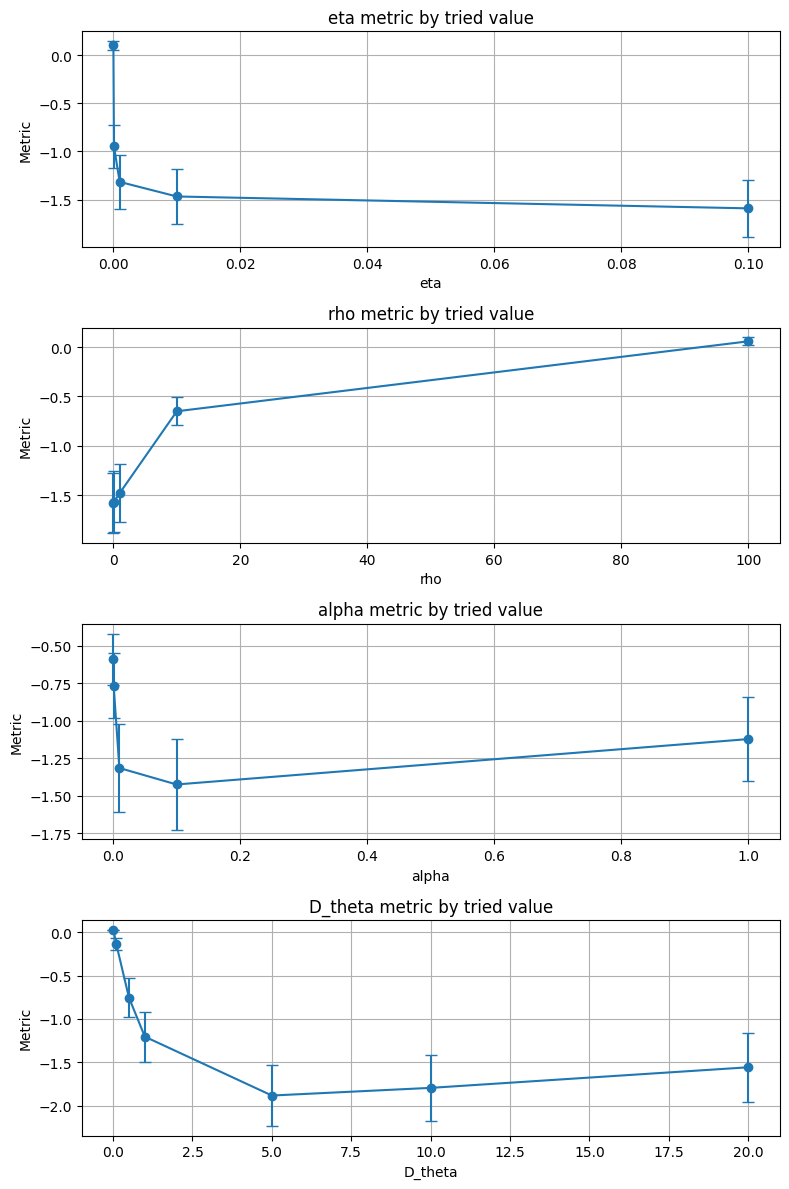

In [22]:
summary = optimizer.optimize(
    mode="grid",
    parameters=("eta", "rho", "alpha", "D_theta"),
    values={
        "alpha": [6e-4, 1e-3, 1e-2, 1e-1, 1],
        "eta": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        "rho": [1e-2, 1e-1, 1.0, 10.0, 100.0],
        "D_theta": [
            0.01, 0.1, 0.5, 1.0, 5.0,
            10.0, 20.0,
        ],
    },
    num_runs=1,
    plot=True,
    print_summary=True,
    progress=True,
)

eta_star = summary["best_params"]["eta"]
rho_star = summary["best_params"]["rho"]
alpha_star = summary["best_params"]["alpha"]
D_theta_star = summary["best_params"]["D_theta"]

In [23]:
solver.run(alpha=alpha_star, eta=eta_star, rho=rho_star, D_theta=D_theta_star, T = 2000, tqdm_print=True)
evaluator.compare_value_functions()

reward_comparison = evaluator.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=5,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison["policy"])
print("Optimal average return:", reward_comparison["optimal"])
print("Gap:", reward_comparison["difference"])

FOGAS Oracle: 100%|██████████████████████████████████████████████████████████████████████| 2000/2000 [00:01<00:00, 1476.91it/s]


========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  6.217100 | V^pi(x) =  6.172940 | delta = -4.416042e-02
State 1: V*(x) =  7.019000 | V^pi(x) =  7.013605 | delta = -5.394726e-03
State 2: V*(x) =  7.910000 | V^pi(x) =  7.908830 | delta = -1.169973e-03
State 3: V*(x) =  7.019000 | V^pi(x) =  7.013605 | delta = -5.394726e-03
State 4: V*(x) =  7.910000 | V^pi(x) =  7.909967 | delta = -3.265530e-05
State 5: V*(x) =  8.900000 | V^pi(x) =  8.899980 | delta = -1.979219e-05
State 6: V*(x) =  7.910000 | V^pi(x) =  7.908830 | delta = -1.169973e-03
State 7: V*(x) =  8.900000 | V^pi(x) =  8.899980 | delta = -1.979219e-05
State 8: V*(x) =  10.000000 | V^pi(x) =  10.000000 | delta =  0.000000e+00

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  5.495390 | Q^pi(x,a) =  5.455646 | delta = -3.974438e-02
(x=0, a=1): Q*(x,a) =  6.217100 | Q^pi(x,a) =  6.212245 | delta = -4.855254e-03
(x=0, a=2): Q*(x,a) =  5.495390 | Q^pi(x,a) =  5.455646 |

### Dataset creation

In [27]:
collector = DiscreteDataBuffer(
    mdp=mdp,
    max_steps=20,
    terminal_states=[goal_grid],
    reset_probs={"x0": 1.0},
    seed=SEED,
)

df = collector.collect(
    policy="random",
    n_steps=500,
    save_path=dataset_path,
    verbose=True,
)

Collected 500 transitions over 33 episodes.
Policy distribution:
policy_id
0    1.0
Name: proportion, dtype: float64
Reset mode distribution:
reset_mode
x0    1.0
Name: proportion, dtype: float64
Saved FOGAS dataset to /shared/home/mauro.diaz/work/FOGAS/data/datasets_clean/3grid.csv


### Empirical

In [29]:
solver_e = FOGASSolver(
    mdp=mdp,
    phi=phi,
    csv_path=dataset_path,
    print_params=True,
    seed=SEED,
    device=DEVICE,
    T = 2000,
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    mdp=mdp,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 20,
        "seed": SEED,
        "terminal_states": [goal_grid],
        "maximize": True,
    },
    seed=SEED,
)


Device: cpu
Dataset: /shared/home/mauro.diaz/work/FOGAS/data/datasets_clean/3grid.csv (n=500)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           500
Feature norm bound R:     1.0000
Num states N:             9
Num actions A:            4
Feature dim d:            36
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      462.7564263195183
T (iterations):                2000   (overridden → 2000)

FOGAS Hyperparameters
---------------------
alpha:                        0.000621
rho:                            870.919017
eta:                            0.000012
D_theta:                    18.973666
beta (ridge):             0.000014
D_pi (derived):           23.548200




Trying same optimal hyperparameters found for the oracle.

In [30]:
solver_e.run(
    alpha=alpha_star,
    eta=eta_star,
    rho=rho_star,
    D_theta=D_theta_star,
    tqdm_print=True,
)

evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=20,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison["policy"])
print("Optimal average return:", reward_comparison["optimal"])
print("Gap:", reward_comparison["difference"])

FOGAS: 100%|██████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:04<00:00, 472.40it/s]



========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  6.217100 | V^pi(x) =  5.591227 | delta = -6.258728e-01
State 1: V*(x) =  7.019000 | V^pi(x) =  6.464701 | delta = -5.542995e-01
State 2: V*(x) =  7.910000 | V^pi(x) =  7.238825 | delta = -6.711748e-01
State 3: V*(x) =  7.019000 | V^pi(x) =  6.521988 | delta = -4.970124e-01
State 4: V*(x) =  7.910000 | V^pi(x) =  7.639252 | delta = -2.707477e-01
State 5: V*(x) =  8.900000 | V^pi(x) =  8.644608 | delta = -2.553923e-01
State 6: V*(x) =  7.910000 | V^pi(x) =  7.285676 | delta = -6.243239e-01
State 7: V*(x) =  8.900000 | V^pi(x) =  8.633969 | delta = -2.660306e-01
State 8: V*(x) =  10.000000 | V^pi(x) =  10.000000 | delta =  0.000000e+00

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  5.495390 | Q^pi(x,a) =  4.932105 | delta = -5.632855e-01
(x=0, a=1): Q*(x,a) =  6.217100 | Q^pi(x,a) =  5.769789 | delta = -4.473111e-01
(x=0, a=2): Q*(x,a) =  5.495390 | Q^pi(x,a) =  4.932105 |

FOGAS hyperopt:   0%|          | 0/750 [00:00<?, ?candidate/s]


=== FOGAS Hyperparameter Optimization ===
Metric: average_return
Mode: grid
Parameters: ('alpha', 'eta', 'D_theta', 'rho')
Evaluated candidates: 750
Best metric: -5.00133
Best params: alpha=1.0000e-01, rho=1.0000e-02, eta=1.0000e-01, T=2000, D_theta=1.0000e+00, D_pi=2.0000e+02

Top 5 candidates:
1. metric=-5.00133 | stage=grid | alpha=1.0000e-01, rho=1.0000e-02, eta=1.0000e-01, T=2000, D_theta=1.0000e+00, D_pi=2.0000e+02
2. metric=-5.00133 | stage=grid | alpha=1.0000e-01, rho=1.0000e-02, eta=1.0000e-01, T=2000, D_theta=5.0000e+00, D_pi=1.0000e+03
3. metric=-5.00133 | stage=grid | alpha=1.0000e-01, rho=1.0000e-02, eta=1.0000e-01, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+03
4. metric=-5.00133 | stage=grid | alpha=1.0000e-01, rho=1.0000e-01, eta=1.0000e-01, T=2000, D_theta=1.0000e+00, D_pi=2.0000e+02
5. metric=-5.00133 | stage=grid | alpha=1.0000e-01, rho=1.0000e-01, eta=1.0000e-01, T=2000, D_theta=5.0000e+00, D_pi=1.0000e+03


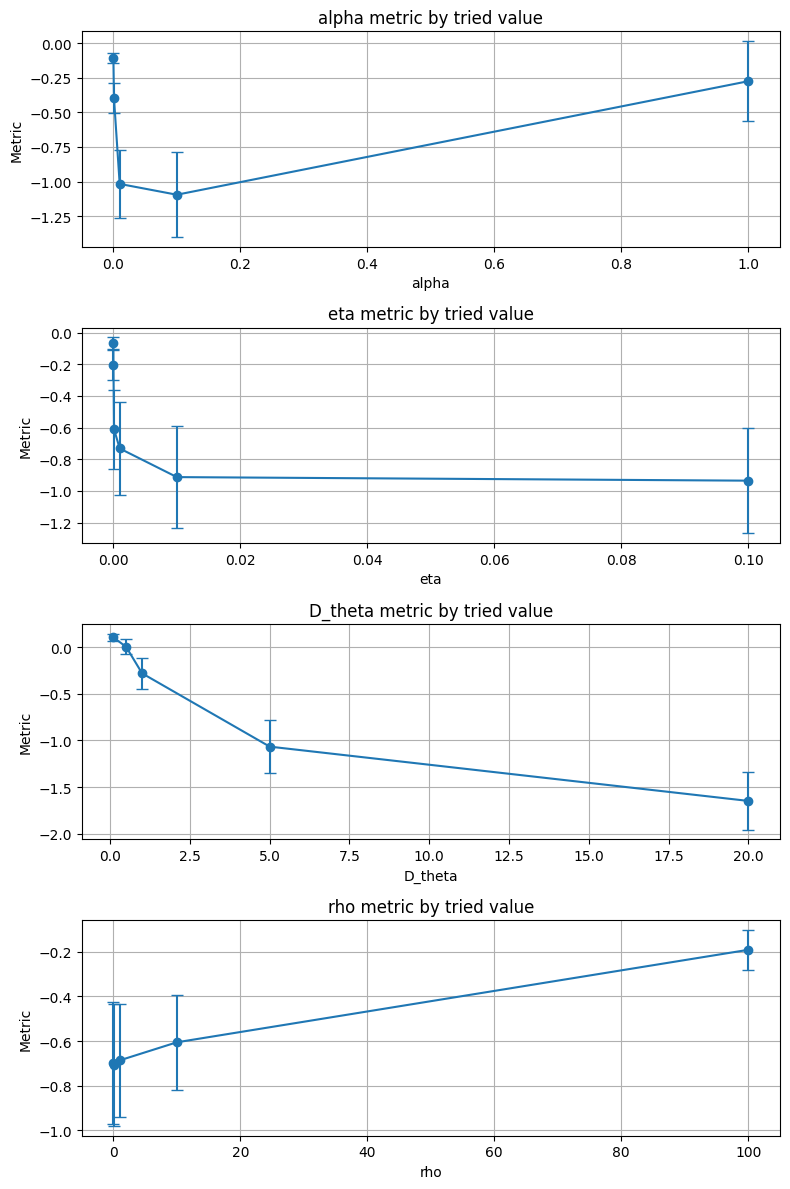

In [31]:
summary_e = optimizer_e.optimize(
    mode="grid",
    parameters=("alpha", "eta", "D_theta", "rho"),
    values={
        "alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1],
        "eta": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        "rho": [1e-2, 1e-1, 1.0, 10.0, 100.0],
        "D_theta": [0.1, 0.5, 1.0, 5.0, 20.0],
    },
    num_runs=1,
    plot=True,
    print_summary=True,
    progress=True,
)

alpha_star_e = summary_e["best_params"]["alpha"]
eta_star_e = summary_e["best_params"]["eta"]
D_theta_star_e = summary_e["best_params"]["D_theta"]
rho_star_e = summary_e["best_params"]["rho"]

In [32]:
solver_e.run(
    alpha=alpha_star_e,
    eta=eta_star_e,
    D_theta=D_theta_star_e,
    rho=rho_star_e,
    tqdm_print=True,
)

evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison_e = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=20,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison_e["policy"])
print("Optimal average return:", reward_comparison_e["optimal"])
print("Gap:", reward_comparison_e["difference"])

FOGAS: 100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 2351.57it/s]



========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  6.217100 | V^pi(x) =  6.217100 | delta = -9.784109e-08
State 1: V*(x) =  7.019000 | V^pi(x) =  7.019000 | delta = -1.978343e-08
State 2: V*(x) =  7.910000 | V^pi(x) =  7.910000 | delta = -1.997328e-09
State 3: V*(x) =  7.019000 | V^pi(x) =  7.019000 | delta = -7.607288e-09
State 4: V*(x) =  7.910000 | V^pi(x) =  7.910000 | delta = -8.899281e-11
State 5: V*(x) =  8.900000 | V^pi(x) =  8.900000 | delta = -9.281287e-11
State 6: V*(x) =  7.910000 | V^pi(x) =  7.910000 | delta = -1.863370e-09
State 7: V*(x) =  8.900000 | V^pi(x) =  8.900000 | delta = -9.922552e-11
State 8: V*(x) =  10.000000 | V^pi(x) =  10.000000 | delta =  0.000000e+00

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  5.495390 | Q^pi(x,a) =  5.495390 | delta = -8.805698e-08
(x=0, a=1): Q*(x,a) =  6.217100 | Q^pi(x,a) =  6.217100 | delta = -6.846559e-09
(x=0, a=2): Q*(x,a) =  5.495390 | Q^pi(x,a) =  5.495390 |

# State-aggregation Features

We did two different state-aggregation features, showing that if the feature of the action with the feature of the state are not mixed, the algorithm will not converge (the policy is completely independent of the state).

## DEFINITION

**Feature Map**

We use a structured linear feature representation over state–action pairs that decomposes into row features, action features, and a terminal indicator.

The state space is a (3 \times 3) grid with
$$
\mathcal{X} = {0,\dots,8}, \quad \mathcal{A} = {0,1,2,3}.
$$

Let $ \text{row}(x) \in \{0,1,2\}$ denote the row index of state (x).
The feature map is defined as
$$
\phi(x,a) \in \mathbb{R}^{d}, \qquad d = 3 * 4 + 1 = 13.
$$

It has the following structure:
$$
\phi(x,a): \; \; (x,a) \;\longrightarrow\; e_{\; \text{row}(x) \; \cdot \; |\mathcal{A}|\; + \; a},
$$

Thus:

* The **first 3 coordinates** encode the row of the grid.
* The **next 4 coordinates** encode the chosen action.
* The **last coordinate** is a terminal-state indicator for the goal state (x=8).

**Reward Weights**

The reward function is linear in the features:
$$
r(x,a) = \phi(x,a)^\top \omega.
$$

The weight vector $\omega \in \mathbb{R}^{8}$ is defined as
$$
\omega =
\begin{bmatrix}
0 \ 0 \ 0 \ 0 \ 0 \ 0 \ 0 \ 0 \ 0 \ 0 \ 0 \ 0 \ 1
\end{bmatrix}.
$$

This yields:
$$
r(x,a) =
\begin{cases}
1 & \text{if } x = 8 \;\; (\text{goal state}), \\
0 & \text{otherwise}.
\end{cases}
$$

**Transition Model**

The transition matrix
$$
P \in \mathbb{R}^{(9\cdot 4) \times 9}
$$
is defined such that each row corresponding to $(x,a)$ contains a single 1 at column $x'$:

$$
P_{(x,a),x'} =
\begin{cases}
1 & \text{if } x' = \text{next\_state}(x,a), \\
0 & \text{otherwise}.
\end{cases}
$$


## Testing

In [ ]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)
N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0
goal = 8

step_cost = -0.1
goal_reward = 1.0


def to_rc(s):
    return divmod(int(s), 3)


def to_s(r, c):
    return r * 3 + c


d_state = N // 3      # row aggregation: 3 rows
d_action = 3          # action aggregation/features
d = d_state * d_action + 2


def phi_state(state):
    row, _ = to_rc(state)
    f = torch.zeros(d_state, dtype=torch.float64)
    f[row] = 1.0
    return f


def phi_action(action):
    action = int(action)

    if action == 0:      # Up
        dr, dc = -1.0, 0.0
    elif action == 1:    # Down
        dr, dc = 1.0, 0.0
    elif action == 2:    # Left
        dr, dc = 0.0, -1.0
    elif action == 3:    # Right
        dr, dc = 0.0, 1.0
    else:
        raise ValueError(f"Unknown action: {action}")

    return torch.tensor([1.0, dr, dc], dtype=torch.float64)


def phi(state, action):
    f = torch.zeros(d, dtype=torch.float64)

    # Aggregated state-action features: row feature kron action feature
    f[: d_state * d_action] = torch.kron(phi_state(state), phi_action(action))

    # Default step-cost bias
    f[-2] = 1.0

    # Goal indicator
    f[-1] = 1.0 if int(state) == goal else 0.0

    return f


omega = torch.zeros(d, dtype=torch.float64)
omega[-2] = step_cost
omega[-1] = goal_reward - step_cost


def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal:
        return goal

    r, c = to_rc(s)

    if a == 0:      # Up
        r = max(0, r - 1)
    elif a == 1:    # Down
        r = min(2, r + 1)
    elif a == 2:    # Left
        c = max(0, c - 1)
    elif a == 3:    # Right
        c = min(2, c + 1)
    else:
        raise ValueError(f"Unknown action: {a}")

    return to_s(r, c)


def transition_fn(s, a):
    probs = torch.zeros(N, dtype=torch.float64)
    probs[next_state(s, a)] = 1.0
    return probs


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    omega=omega,
    phi=phi,
    transition_fn=transition_fn,
    terminal_states=[goal],
)

planner = Planner(mdp, mode="deterministic")

### Empirical

In [36]:
solver_e = FOGASSolver(
    mdp=mdp,
    phi=phi,
    csv_path=dataset_path,
    print_params=True,
    seed=SEED,
    device=DEVICE,
    T = 2000,
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    mdp=mdp,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 20,
        "seed": SEED,
        "terminal_states": [goal],
        "maximize": True,
    },
    seed=SEED,
)


Device: cpu
Dataset: /shared/home/mauro.diaz/work/FOGAS/data/datasets_clean/3grid.csv (n=500)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           500
Feature norm bound R:     2.0000
Num states N:             9
Num actions A:            4
Feature dim d:            11
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      1851.0257052780732
T (iterations):                2000   (overridden → 2000)

FOGAS Hyperparameters
---------------------
alpha:                        0.000561
rho:                            266.114144
eta:                            0.000020
D_theta:                    10.488088
beta (ridge):             0.000182
D_pi (derived):           11.774100




FOGAS hyperopt:   0%|          | 0/750 [00:00<?, ?candidate/s]


=== FOGAS Hyperparameter Optimization ===
Metric: average_return
Mode: grid
Parameters: ('alpha', 'eta', 'D_theta', 'rho')
Evaluated candidates: 750
Best metric: -2.25188
Best params: alpha=1.0000e-01, rho=1.0000e+01, eta=1.0000e-01, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+03

Top 5 candidates:
1. metric=-2.25188 | stage=grid | alpha=1.0000e-01, rho=1.0000e+01, eta=1.0000e-01, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+03
2. metric=-1.71799 | stage=grid | alpha=1.0000e+00, rho=1.0000e+00, eta=1.0000e-02, T=2000, D_theta=5.0000e+00, D_pi=1.0000e+04
3. metric=-1.60648 | stage=grid | alpha=1.0000e+00, rho=1.0000e-02, eta=1.0000e-02, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+04
4. metric=-1.4698 | stage=grid | alpha=1.0000e+00, rho=1.0000e+00, eta=1.0000e-03, T=2000, D_theta=5.0000e+00, D_pi=1.0000e+04
5. metric=-1.46454 | stage=grid | alpha=1.0000e-02, rho=1.0000e-02, eta=1.0000e-01, T=2000, D_theta=5.0000e-01, D_pi=1.0000e+01


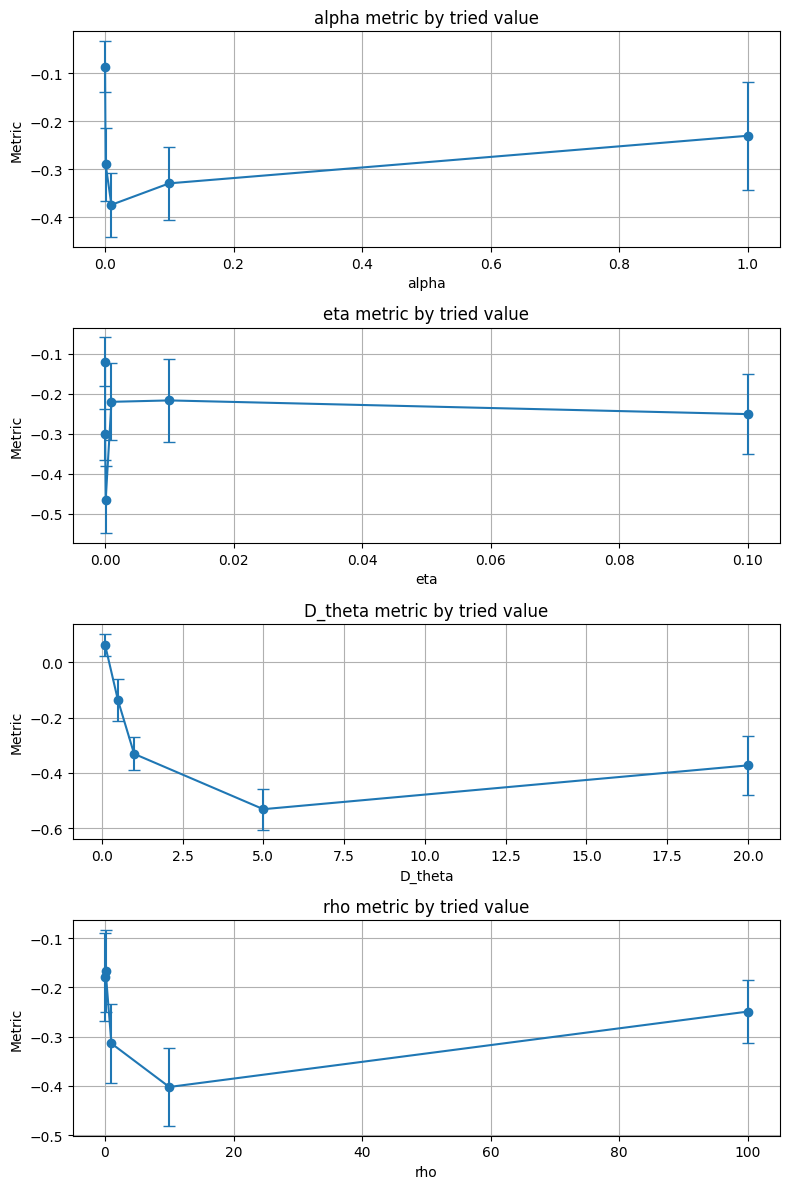

In [37]:
summary_e = optimizer_e.optimize(
    mode="grid",
    parameters=("alpha", "eta", "D_theta", "rho"),
    values={
        "alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1],
        "eta": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        "rho": [1e-2, 1e-1, 1.0, 10.0, 100.0],
        "D_theta": [0.1, 0.5, 1.0, 5.0, 20.0],
    },
    num_runs=1,
    plot=True,
    print_summary=True,
    progress=True,
)

alpha_star_e = summary_e["best_params"]["alpha"]
eta_star_e = summary_e["best_params"]["eta"]
D_theta_star_e = summary_e["best_params"]["D_theta"]
rho_star_e = summary_e["best_params"]["rho"]

Doesnt work because of the actions state aggregation!

In [38]:
solver_e.run(
    alpha=alpha_star_e,
    eta=eta_star_e,
    D_theta=D_theta_star_e,
    rho=rho_star_e,
    tqdm_print=True,
)

evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison_e = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=20,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison_e["policy"])
print("Optimal average return:", reward_comparison_e["optimal"])
print("Gap:", reward_comparison_e["difference"])

FOGAS: 100%|██████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 2794.54it/s]


========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  6.217100 | V^pi(x) =  3.120277 | delta = -3.096823e+00
State 1: V*(x) =  7.019000 | V^pi(x) =  4.932462 | delta = -2.086538e+00
State 2: V*(x) =  7.910000 | V^pi(x) =  7.150965 | delta = -7.590350e-01
State 3: V*(x) =  7.019000 | V^pi(x) =  2.316862 | delta = -4.702138e+00
State 4: V*(x) =  7.910000 | V^pi(x) =  4.139535 | delta = -3.770465e+00
State 5: V*(x) =  8.900000 | V^pi(x) =  8.900000 | delta = -3.840075e-10
State 6: V*(x) =  7.910000 | V^pi(x) =  2.685403 | delta = -5.224597e+00
State 7: V*(x) =  8.900000 | V^pi(x) =  4.710594 | delta = -4.189406e+00
State 8: V*(x) =  10.000000 | V^pi(x) =  10.000000 | delta =  0.000000e+00

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  5.495390 | Q^pi(x,a) =  2.708250 | delta = -2.787140e+00
(x=0, a=1): Q*(x,a) =  6.217100 | Q^pi(x,a) =  1.985176 | delta = -4.231924e+00
(x=0, a=2): Q*(x,a) =  5.495390 | Q^pi(x,a) =  2.708250 |

In [39]:
evaluator_e.print_solver_policy()

  State 0: pi(a=0|s=0) = 0.00  pi(a=1|s=0) = 0.52  pi(a=2|s=0) = 0.00  pi(a=3|s=0) = 0.48  --> best action: 1
  State 1: pi(a=0|s=1) = 0.00  pi(a=1|s=1) = 0.52  pi(a=2|s=1) = 0.00  pi(a=3|s=1) = 0.48  --> best action: 1
  State 2: pi(a=0|s=2) = 0.00  pi(a=1|s=2) = 0.52  pi(a=2|s=2) = 0.00  pi(a=3|s=2) = 0.48  --> best action: 1
  State 3: pi(a=0|s=3) = 0.00  pi(a=1|s=3) = 1.00  pi(a=2|s=3) = 0.00  pi(a=3|s=3) = 0.00  --> best action: 1
  State 4: pi(a=0|s=4) = 0.00  pi(a=1|s=4) = 1.00  pi(a=2|s=4) = 0.00  pi(a=3|s=4) = 0.00  --> best action: 1
  State 5: pi(a=0|s=5) = 0.00  pi(a=1|s=5) = 1.00  pi(a=2|s=5) = 0.00  pi(a=3|s=5) = 0.00  --> best action: 1
  State 6: pi(a=0|s=6) = 0.21  pi(a=1|s=6) = 0.29  pi(a=2|s=6) = 0.26  pi(a=3|s=6) = 0.24  --> best action: 1
  State 7: pi(a=0|s=7) = 0.21  pi(a=1|s=7) = 0.29  pi(a=2|s=7) = 0.26  pi(a=3|s=7) = 0.24  --> best action: 1
  State 8: pi(a=0|s=8) = 0.21  pi(a=1|s=8) = 0.29  pi(a=2|s=8) = 0.26  pi(a=3|s=8) = 0.24  --> best action: 1



In [40]:
evaluator_e.print_optimal_policy()

  State 0: pi(a=0|s=0) = 0.00  pi(a=1|s=0) = 1.00  pi(a=2|s=0) = 0.00  pi(a=3|s=0) = 0.00  --> best action: 1
  State 1: pi(a=0|s=1) = 0.00  pi(a=1|s=1) = 1.00  pi(a=2|s=1) = 0.00  pi(a=3|s=1) = 0.00  --> best action: 1
  State 2: pi(a=0|s=2) = 0.00  pi(a=1|s=2) = 1.00  pi(a=2|s=2) = 0.00  pi(a=3|s=2) = 0.00  --> best action: 1
  State 3: pi(a=0|s=3) = 0.00  pi(a=1|s=3) = 1.00  pi(a=2|s=3) = 0.00  pi(a=3|s=3) = 0.00  --> best action: 1
  State 4: pi(a=0|s=4) = 0.00  pi(a=1|s=4) = 1.00  pi(a=2|s=4) = 0.00  pi(a=3|s=4) = 0.00  --> best action: 1
  State 5: pi(a=0|s=5) = 0.00  pi(a=1|s=5) = 1.00  pi(a=2|s=5) = 0.00  pi(a=3|s=5) = 0.00  --> best action: 1
  State 6: pi(a=0|s=6) = 0.00  pi(a=1|s=6) = 0.00  pi(a=2|s=6) = 0.00  pi(a=3|s=6) = 1.00  --> best action: 3
  State 7: pi(a=0|s=7) = 0.00  pi(a=1|s=7) = 0.00  pi(a=2|s=7) = 0.00  pi(a=3|s=7) = 1.00  --> best action: 3
  State 8: pi(a=0|s=8) = 1.00  pi(a=1|s=8) = 0.00  pi(a=2|s=8) = 0.00  pi(a=3|s=8) = 0.00  --> best action: 0



One hot encoding in actions (?)

In [45]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)
N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0
goal = 8

step_cost = -0.1
goal_reward = 1.0


def to_rc(s):
    return divmod(int(s), 3)


def to_s(r, c):
    return r * 3 + c


# 3 rows * 4 actions + step-cost bias + goal indicator
d = (N // 3) * A + 2


def phi(state, action):
    row, _ = to_rc(state)
    f = torch.zeros(d, dtype=torch.float64)

    # Row-action feature
    f[row * A + int(action)] = 1.0

    # Default step-cost bias
    f[-2] = 1.0

    # Goal indicator
    f[-1] = 1.0 if int(state) == goal else 0.0

    return f


omega = torch.zeros(d, dtype=torch.float64)
omega[-2] = step_cost
omega[-1] = goal_reward - step_cost


def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal:
        return goal

    r, c = to_rc(s)

    if a == 0:      # Up
        r = max(0, r - 1)
    elif a == 1:    # Down
        r = min(2, r + 1)
    elif a == 2:    # Left
        c = max(0, c - 1)
    elif a == 3:    # Right
        c = min(2, c + 1)
    else:
        raise ValueError(f"Unknown action: {a}")

    return to_s(r, c)


def transition_fn(s, a):
    probs = torch.zeros(N, dtype=torch.float64)
    probs[next_state(s, a)] = 1.0
    return probs


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    omega=omega,
    phi=phi,
    transition_fn=transition_fn,
    terminal_states=[goal],
)

planner = Planner(mdp, mode="deterministic")

In [46]:
solver_e = FOGASSolver(
    mdp=mdp,
    phi=phi,
    csv_path=dataset_path,
    print_params=True,
    seed=SEED,
    device=DEVICE,
    T = 2000,
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    mdp=mdp,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 20,
        "seed": SEED,
        "terminal_states": [goal],
        "maximize": True,
    },
    seed=SEED,
)


Device: cpu
Dataset: /shared/home/mauro.diaz/work/FOGAS/data/datasets_clean/3grid.csv (n=500)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           500
Feature norm bound R:     1.7321
Num states N:             9
Num actions A:            4
Feature dim d:            14
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      1388.2692789585549
T (iterations):                2000   (overridden → 2000)

FOGAS Hyperparameters
---------------------
alpha:                        0.000575
rho:                            338.690729
eta:                            0.000018
D_theta:                    11.832160
beta (ridge):             0.000107
D_pi (derived):           13.595560




FOGAS hyperopt:   0%|          | 0/750 [00:00<?, ?candidate/s]


=== FOGAS Hyperparameter Optimization ===
Metric: average_return
Mode: grid
Parameters: ('alpha', 'eta', 'D_theta', 'rho')
Evaluated candidates: 750
Best metric: -5.00133
Best params: alpha=1.0000e-01, rho=1.0000e-02, eta=1.0000e-02, T=2000, D_theta=5.0000e-01, D_pi=1.0000e+02

Top 5 candidates:
1. metric=-5.00133 | stage=grid | alpha=1.0000e-01, rho=1.0000e-02, eta=1.0000e-02, T=2000, D_theta=5.0000e-01, D_pi=1.0000e+02
2. metric=-5.00133 | stage=grid | alpha=1.0000e-01, rho=1.0000e-01, eta=1.0000e-02, T=2000, D_theta=5.0000e-01, D_pi=1.0000e+02
3. metric=-5.00133 | stage=grid | alpha=1.0000e-01, rho=1.0000e-02, eta=1.0000e-01, T=2000, D_theta=5.0000e-01, D_pi=1.0000e+02
4. metric=-5.00133 | stage=grid | alpha=1.0000e-01, rho=1.0000e-01, eta=1.0000e-01, T=2000, D_theta=5.0000e-01, D_pi=1.0000e+02
5. metric=-5.00133 | stage=grid | alpha=1.0000e+00, rho=1.0000e-02, eta=1.0000e-02, T=2000, D_theta=5.0000e-01, D_pi=1.0000e+03


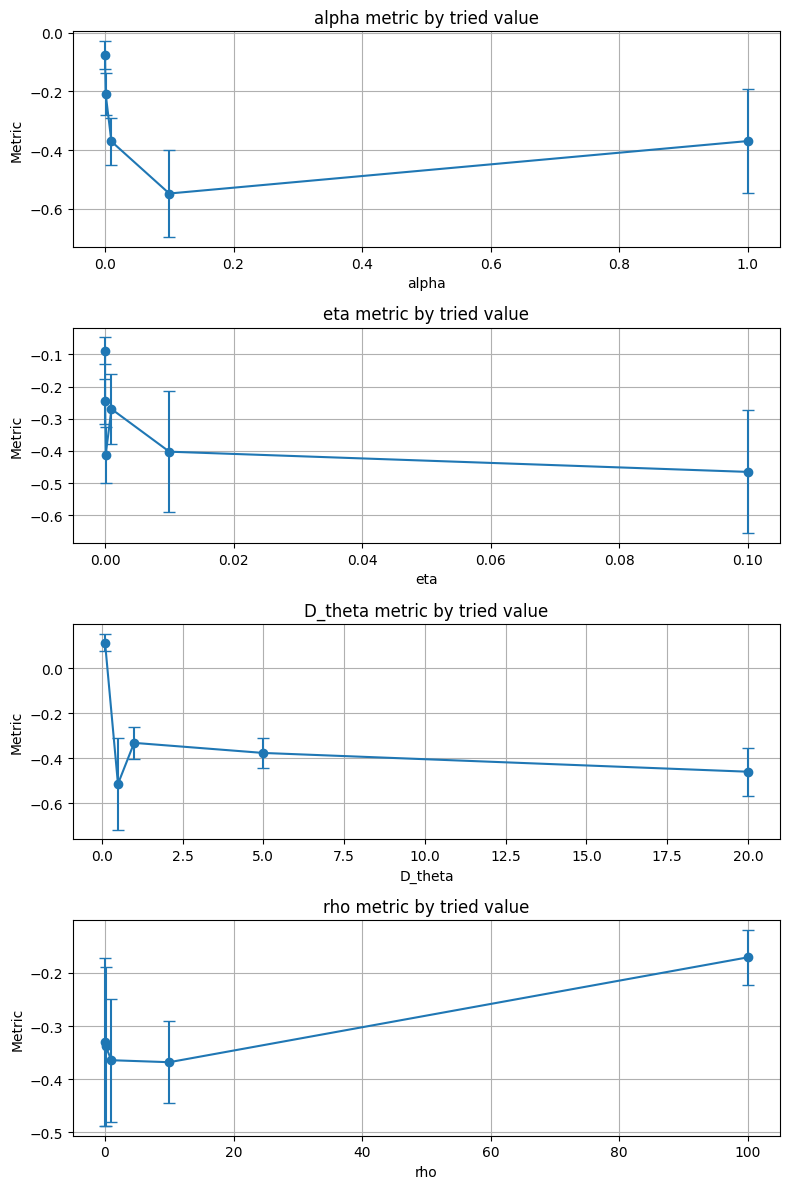

In [47]:
summary_e = optimizer_e.optimize(
    mode="grid",
    parameters=("alpha", "eta", "D_theta", "rho"),
    values={
        "alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1],
        "eta": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        "rho": [1e-2, 1e-1, 1.0, 10.0, 100.0],
        "D_theta": [0.1, 0.5, 1.0, 5.0, 20.0],
    },
    num_runs=1,
    plot=True,
    print_summary=True,
    progress=True,
)

alpha_star_e = summary_e["best_params"]["alpha"]
eta_star_e = summary_e["best_params"]["eta"]
D_theta_star_e = summary_e["best_params"]["D_theta"]
rho_star_e = summary_e["best_params"]["rho"]

In [48]:
solver_e.run(
    alpha=alpha_star_e,
    eta=eta_star_e,
    D_theta=D_theta_star_e,
    rho=rho_star_e,
    tqdm_print=True,
)

evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison_e = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=20,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison_e["policy"])
print("Optimal average return:", reward_comparison_e["optimal"])
print("Gap:", reward_comparison_e["difference"])

FOGAS: 100%|████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 2724.42it/s]


========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  6.217100 | V^pi(x) =  6.216825 | delta = -2.753962e-04
State 1: V*(x) =  7.019000 | V^pi(x) =  7.018543 | delta = -4.566340e-04
State 2: V*(x) =  7.910000 | V^pi(x) =  7.909243 | delta = -7.567501e-04
State 3: V*(x) =  7.019000 | V^pi(x) =  7.018979 | delta = -2.086907e-05
State 4: V*(x) =  7.910000 | V^pi(x) =  7.909965 | delta = -3.454259e-05
State 5: V*(x) =  8.900000 | V^pi(x) =  8.899956 | delta = -4.426572e-05
State 6: V*(x) =  7.910000 | V^pi(x) =  7.909993 | delta = -7.291996e-06
State 7: V*(x) =  8.900000 | V^pi(x) =  8.899995 | delta = -4.825463e-06
State 8: V*(x) =  10.000000 | V^pi(x) =  10.000000 | delta =  0.000000e+00

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  5.495390 | Q^pi(x,a) =  5.495142 | delta = -2.478566e-04
(x=0, a=1): Q*(x,a) =  6.217100 | Q^pi(x,a) =  6.217081 | delta = -1.878216e-05
(x=0, a=2): Q*(x,a) =  5.495390 | Q^pi(x,a) =  5.495142 |